# Lecture 01: Environment Setup & JAX Basics

**Machine Learning Applications in Physics (PHYG004)** — Sogang University, 2026 Spring

---

## Overview

In this tutorial, we will:

1. Install and verify JAX
2. Learn basic JAX array operations
3. Understand JAX's random number system
4. Compare NumPy vs JAX (key differences)
5. Use automatic differentiation with `jax.grad`
6. Try JIT compilation for speed

## Learning Objectives

- Set up a working JAX environment (Colab or local)
- Perform basic array and math operations in JAX
- Understand why JAX uses explicit PRNG keys
- Compute derivatives of Python functions using `jax.grad`
- Apply `jax.jit` to speed up computations

In [1]:
# Install dependencies (run this on Google Colab)
!pip install -q jax jaxlib optax flax matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [2]:
import jax
import jax.numpy as jnp
import jax.random as random
import numpy as np
import matplotlib.pyplot as plt

# Check JAX version and available devices
print(f"JAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")

JAX version: 0.9.1
Available devices: [CpuDevice(id=0)]
Backend: cpu


### Device Check

- On **Google Colab** with GPU enabled: you should see a `cuda` or `gpu` device.
- On a **local machine** without GPU: you'll see `cpu`, which is fine for this tutorial.

To enable GPU on Colab: **Runtime → Change runtime type → GPU**

---
## 1. Basic JAX Operations

JAX provides a NumPy-compatible API via `jax.numpy`. If you know NumPy, you already know most of JAX!

In [3]:
# Creating arrays
a = jnp.array([1.0, 2.0, 3.0, 4.0])
print(f"a = {a}")
print(f"a.shape = {a.shape}, a.dtype = {a.dtype}")

# Common array constructors
zeros = jnp.zeros((2, 3))
ones = jnp.ones((3, 2))
x = jnp.linspace(0, 2 * jnp.pi, 100)  # 100 points from 0 to 2*pi

print(f"\nzeros shape: {zeros.shape}")
print(f"ones shape: {ones.shape}")
print(f"linspace shape: {x.shape}, range: [{x[0]:.2f}, {x[-1]:.2f}]")

a = [1. 2. 3. 4.]
a.shape = (4,), a.dtype = float32

zeros shape: (2, 3)
ones shape: (3, 2)
linspace shape: (100,), range: [0.00, 6.28]


In [4]:
# Element-wise operations
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([4.0, 5.0, 6.0])

print(f"a + b = {a + b}")
print(f"a * b = {a * b}")
print(f"a ** 2 = {a ** 2}")

# Dot product
dot = jnp.dot(a, b)
print(f"\na · b = {dot}")

# Trigonometric functions
x = jnp.linspace(0, 2 * jnp.pi, 5)
print(f"\nsin(x) = {jnp.sin(x)}")

a + b = [5. 7. 9.]
a * b = [ 4. 10. 18.]
a ** 2 = [1. 4. 9.]

a · b = 32.0

sin(x) = [ 0.0000000e+00  1.0000000e+00 -8.7422777e-08 -1.0000000e+00
  1.7484555e-07]


---
## 2. Random Numbers in JAX

JAX handles randomness differently from NumPy. Instead of a global random state, JAX uses **explicit PRNG keys**. This is important for:

- **Reproducibility**: the same key always produces the same result
- **Parallelism**: independent keys can be used on different devices
- **Functional purity**: no hidden global state

In [5]:
# Create a PRNG key
key = random.PRNGKey(42)
print(f"Key: {key}")

# Generate random numbers
x = random.normal(key, shape=(5,))
print(f"\nRandom normal: {x}")

# IMPORTANT: Using the same key gives the same result!
x_again = random.normal(key, shape=(5,))
print(f"Same key again: {x_again}")
print(f"Are they equal? {jnp.allclose(x, x_again)}")

# To get different random numbers, split the key
key, subkey1, subkey2 = random.split(key, 3)
y1 = random.normal(subkey1, shape=(3,))
y2 = random.normal(subkey2, shape=(3,))
print(f"\ny1 = {y1}")
print(f"y2 = {y2}")
print(f"Are y1 and y2 different? {not jnp.allclose(y1, y2)}")

Key: [ 0 42]

Random normal: [-0.02830462  0.46713185  0.29570296  0.15354592 -0.12403282]
Same key again: [-0.02830462  0.46713185  0.29570296  0.15354592 -0.12403282]
Are they equal? True

y1 = [ 0.60576403  0.7990441  -0.908927  ]
y2 = [ 0.4323065  0.5872638 -1.1416743]
Are y1 and y2 different? True


W0304 00:16:55.821629 24129018 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


---
## 3. NumPy vs JAX: Key Differences

The most important difference: **JAX arrays are immutable**. You cannot modify them in-place.

In [ ]:
# NumPy: in-place modification works
np_arr = np.array([1, 2, 3, 4, 5])
np_arr[2] = 99
print(f"NumPy (in-place): {np_arr}")

# JAX: in-place modification raises an error!
jax_arr = jnp.array([1, 2, 3, 4, 5])
try:
    jax_arr[2] = 99
except TypeError as e:
    print(f"\nJAX error: {e}")

# JAX: use .at[].set() to create a NEW array with the change
jax_arr_new = jax_arr.at[2].set(99)
print(f"\nOriginal JAX array: {jax_arr}")
print(f"New JAX array:      {jax_arr_new}")

---
## 4. Matrix Multiplication Benchmark

Let's compare NumPy and JAX performance on matrix multiplication. On GPU, JAX should be significantly faster for large matrices.

In [10]:
import time

size = 2000

# NumPy matmul
np_a = np.random.randn(size, size).astype(np.float32)
np_b = np.random.randn(size, size).astype(np.float32)

start = time.time()
np_result = np_a @ np_b
np_time = time.time() - start
print(f"NumPy matmul ({size}x{size}): {np_time:.4f} sec")

# JAX matmul
jax_a = jnp.array(np_a)
jax_b = jnp.array(np_b)

# Warm-up (first call includes compilation)
_ = (jax_a @ jax_b).block_until_ready()

start = time.time()
jax_result = (jax_a @ jax_b).block_until_ready()
jax_time = time.time() - start
print(f"JAX matmul   ({size}x{size}): {jax_time:.4f} sec")

print(f"\nResults match: {np.allclose(np_result, jax_result, atol=1e-2)}")
print(f"Speedup: {np_time / jax_time:.1f}x")

NumPy matmul (2000x2000): 0.0094 sec
JAX matmul   (2000x2000): 0.0151 sec

Results match: True
Speedup: 0.6x


/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_44266/1093362793.py:10: RuntimeWarning: divide by zero encountered in matmul
  np_result = np_a @ np_b
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_44266/1093362793.py:10: RuntimeWarning: overflow encountered in matmul
  np_result = np_a @ np_b
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_44266/1093362793.py:10: RuntimeWarning: invalid value encountered in matmul
  np_result = np_a @ np_b


---
## 5. Automatic Differentiation with `jax.grad`

This is one of JAX's most powerful features. `jax.grad` can differentiate any Python function!

In physics, we constantly need derivatives:
- Force = $-\nabla V$ (gradient of potential energy)
- Equations of motion from Lagrangian $\mathcal{L}$
- Response functions, susceptibilities, ...

JAX computes **exact** (not numerical) derivatives via automatic differentiation.

In [6]:
# Define a simple function: f(x) = x^3 + 2x^2 - 5x + 3
def f(x):
    return x**3 + 2*x**2 - 5*x + 3

# First derivative: f'(x) = 3x^2 + 4x - 5
df = jax.grad(f)

# Second derivative: f''(x) = 6x + 4
d2f = jax.grad(jax.grad(f))

x0 = 2.0
print(f"f({x0})   = {f(x0)}")
print(f"f'({x0})  = {df(x0)}  (expected: 3*4 + 4*2 - 5 = {3*x0**2 + 4*x0 - 5})")
print(f"f''({x0}) = {d2f(x0)}  (expected: 6*2 + 4 = {6*x0 + 4})")

f(2.0)   = 9.0
f'(2.0)  = 15.0  (expected: 3*4 + 4*2 - 5 = 15.0)
f''(2.0) = 16.0  (expected: 6*2 + 4 = 16.0)


In [7]:
# Physics example: Harmonic oscillator potential
# V(x) = 0.5 * k * x^2
# Force: F(x) = -dV/dx = -k * x

k = 2.0  # spring constant

def potential(x):
    return 0.5 * k * x**2

# Force = negative gradient of potential
force = jax.grad(lambda x: -potential(x))

# Test at several positions
positions = jnp.array([-2.0, -1.0, 0.0, 1.0, 2.0])
for x_val in positions:
    F = force(float(x_val))
    print(f"x = {x_val:+.1f}  →  V = {potential(x_val):.1f},  F = {F:+.1f}  (expected: {-k*x_val:+.1f})")

x = -2.0  →  V = 4.0,  F = +4.0  (expected: +4.0)
x = -1.0  →  V = 1.0,  F = +2.0  (expected: +2.0)
x = +0.0  →  V = 0.0,  F = -0.0  (expected: -0.0)
x = +1.0  →  V = 1.0,  F = -2.0  (expected: -2.0)
x = +2.0  →  V = 4.0,  F = -4.0  (expected: -4.0)


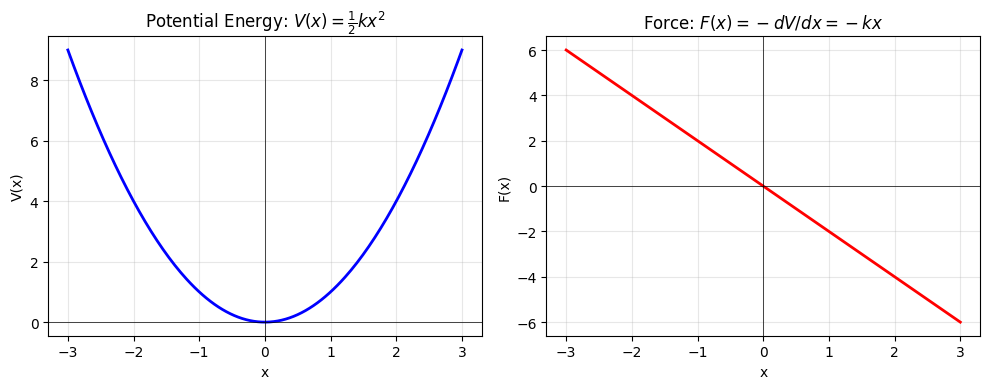

The force is computed automatically from the potential using jax.grad!


In [8]:
# Plot potential energy and force side by side
x = jnp.linspace(-3, 3, 200)
V = jax.vmap(potential)(x)
F = jax.vmap(jax.grad(lambda x: -potential(x)))(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, V, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')
ax1.set_title('Potential Energy: $V(x) = \\frac{1}{2}kx^2$')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

ax2.plot(x, F, 'r-', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')
ax2.set_title('Force: $F(x) = -dV/dx = -kx$')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("The force is computed automatically from the potential using jax.grad!")

---
## 6. Bonus: JIT Compilation

`jax.jit` compiles a function using XLA (Accelerated Linear Algebra) for faster execution. The first call is slow (compilation), but subsequent calls are fast.

In [11]:
def slow_fn(x):
    """A function with many operations."""
    for _ in range(50):
        x = x @ x / jnp.linalg.norm(x)
    return x

fast_fn = jax.jit(slow_fn)

key = random.PRNGKey(0)
x = random.normal(key, (100, 100))

# Warm up JIT (includes compilation time)
_ = fast_fn(x).block_until_ready()

# Benchmark without JIT
start = time.time()
for _ in range(5):
    _ = slow_fn(x).block_until_ready()
no_jit_time = (time.time() - start) / 5

# Benchmark with JIT
start = time.time()
for _ in range(5):
    _ = fast_fn(x).block_until_ready()
jit_time = (time.time() - start) / 5

print(f"Without JIT: {no_jit_time:.4f} sec")
print(f"With JIT:    {jit_time:.4f} sec")
print(f"Speedup:     {no_jit_time / jit_time:.1f}x")

Without JIT: 0.0099 sec
With JIT:    0.0008 sec
Speedup:     12.5x


---
## Summary

| Feature | What we learned |
|---|---|
| **Arrays** | `jnp.array`, `jnp.zeros`, `jnp.ones`, `jnp.linspace` |
| **Operations** | Element-wise ops, `jnp.dot`, `jnp.sin`, `@` for matmul |
| **Random numbers** | `random.PRNGKey`, `random.normal`, `random.split` |
| **Immutability** | Use `.at[].set()` instead of in-place assignment |
| **Autodiff** | `jax.grad(f)` returns a function that computes $df/dx$ |
| **JIT** | `jax.jit(f)` compiles `f` for faster execution |

### Next Week

**Lecture 02: Neural Networks Basics** — linear models, multilayer perceptrons, activation functions

### Resources

- JAX documentation: [docs.jax.dev](https://docs.jax.dev)
- JAX quickstart: [docs.jax.dev/en/latest/quickstart.html](https://docs.jax.dev/en/latest/quickstart.html)